In [1]:
import sys, os
ROOT = os.path.abspath("..")   # go up one directory from notebooks/
if ROOT not in sys.path:
    sys.path.append(ROOT)

print(ROOT)  


c:\Users\tdiks\Documents\PhD NITH\research paper\7th paper\piezo-visco PINN\pinn_FGM_loosley


In [2]:
from src.networks import get_all_networks
from src.config import CONFIG

from src.sampling import (
    sample_domain_points,
    sample_top_surface,
    sample_interface,
    sample_far_field
)

from src.losses import total_loss

from src.pde_residual import (
    residual_layer_FGM,
    residual_halfspace_FGM
)
from src.boundary_conditions import (
    top_surface_bc,
    imperfect_interface_bc,
    halfspace_far_field_bc
)


In [3]:
import torch
import torch.optim as optim

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)


Device: cpu


In [4]:
model_layer, model_half = get_all_networks()

model_layer.to(DEVICE)
model_half.to(DEVICE)


PINN(
  (model): Sequential(
    (0): Linear(in_features=1, out_features=50, bias=True)
    (1): Tanh()
    (2): Linear(in_features=50, out_features=50, bias=True)
    (3): Tanh()
    (4): Linear(in_features=50, out_features=50, bias=True)
    (5): Tanh()
    (6): Linear(in_features=50, out_features=50, bias=True)
    (7): Tanh()
    (8): Linear(in_features=50, out_features=50, bias=True)
    (9): Tanh()
    (10): Linear(in_features=50, out_features=50, bias=True)
    (11): Tanh()
    (12): Linear(in_features=50, out_features=50, bias=True)
    (13): Tanh()
    (14): Linear(in_features=50, out_features=50, bias=True)
    (15): Tanh()
    (16): Linear(in_features=50, out_features=1, bias=True)
  )
)

In [5]:
geom = CONFIG["GEOMETRY"]

# Convert parameter dict values to tensors on DEVICE to preserve
# gradient/device consistency inside residual computations
params_layer_raw = CONFIG["LAYER"]
params_half_raw  = CONFIG["SUBSTRATE"]
import torch
params_layer = {
    kk: torch.tensor(v, device=DEVICE) if not isinstance(v, torch.Tensor) else v.to(DEVICE)
    for kk, v in params_layer_raw.items()
}
params_half = {
    kk: torch.tensor(v, device=DEVICE) if not isinstance(v, torch.Tensor) else v.to(DEVICE)
    for kk, v in params_half_raw.items()
}
dispersion = []   # <-- DEFINE DISPERSION HERE


In [6]:
c = torch.nn.Parameter(
    torch.tensor(
        (params_layer["mu_0"] / params_layer["rho_0"])**0.5,
        device=DEVICE
    )
)


C:\Users\tdiks\AppData\Local\Temp\ipykernel_16716\2063034136.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(


In [7]:
optimizer = optim.Adam(
    list(model_layer.parameters()) +
    list(model_half.parameters()) +
    [c],
    lr=1e-2
)


In [8]:
# Training Loop (Dispersion)
k_values = torch.linspace(
    CONFIG["WAVENUMBER"]["k_min"],
    CONFIG["WAVENUMBER"]["k_max"],
    CONFIG["WAVENUMBER"]["num_k"]
)
k_values

tensor([0.0520, 0.0652, 0.0784, 0.0916, 0.1048, 0.1180, 0.1312, 0.1444, 0.1576,
        0.1708, 0.1840, 0.1972, 0.2104, 0.2236, 0.2368, 0.2500])

In [9]:
import torch
import torch.optim as optim

from src.networks import get_all_networks
from src.config import CONFIG
from src.sampling import (
    sample_domain_points,
    sample_top_surface,
    sample_interface,
    sample_far_field
)
from src.losses import total_loss

# --------------------------------------------------
# Device
# --------------------------------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# --------------------------------------------------
# Geometry and parameters
# --------------------------------------------------
geom = CONFIG["GEOMETRY"]
wavenumber = CONFIG["WAVENUMBER"]

params_layer = CONFIG["LAYER"]
params_half  = CONFIG["SUBSTRATE"]

# Convert to tensors
params_layer = {k: torch.tensor(v, dtype=torch.float32, device=DEVICE) if isinstance(v, (int,float)) else v
                for k,v in params_layer.items()}
params_half  = {k: torch.tensor(v, dtype=torch.float32, device=DEVICE) if isinstance(v, (int,float)) else v
                for k,v in params_half.items()}

# --------------------------------------------------
# Build models ONCE
# --------------------------------------------------
model_layer, model_half = get_all_networks()
model_layer.to(DEVICE)
model_half.to(DEVICE)

dispersion = []

# --------------------------------------------------
# Compute shear wave velocities
# --------------------------------------------------
c_shear_layer = torch.sqrt(params_layer["mu_0"] / params_layer["rho_0"])
c_shear_half  = torch.sqrt(params_half["mu_0"] / params_half["rho_0"])

print("\n=== LOVE-WAVE PHYSICS CHECK ===")
print(f"c_shear_layer = {c_shear_layer.item():.3f}")
print(f"c_shear_half  = {c_shear_half.item():.3f}")
print("Constraint enforced via sigmoid")
print("================================\n")

# --------------------------------------------------
# Loop over wavenumbers
# --------------------------------------------------
k_values = torch.linspace(wavenumber["k_min"], wavenumber["k_max"], wavenumber["num_k"])

loss_history_all = {}
for idx, k in enumerate(k_values):

    k = k.to(DEVICE)

    print(f"\n{'='*60}")
    print(f"Training for k = {k.item():.3f}")
    print(f"{'='*60}")

    loss_history_all[k.item()] = {
    "total": [],
    "pde": [],
    "bc": []
}
    # --------------------------------------------
    # Define bounds
    # --------------------------------------------
    lower = 1.05 * c_shear_layer

    if idx == 0:
        upper = 1.01 * c_shear_half
    else:
        prev_c = torch.tensor(dispersion[-1][1], device=DEVICE)
        upper = torch.minimum(1.01 * c_shear_half, prev_c * 0.99)

    # --------------------------------------------
    # Trainable variable (UNCONSTRAINED)
    # --------------------------------------------
    c_raw = torch.nn.Parameter(torch.tensor(1.0, device=DEVICE))

    # --------------------------------------------
    # Optimizers
    # --------------------------------------------
    optimizer_nets = optim.Adam(
        list(model_layer.parameters()) + list(model_half.parameters()),
        lr=1e-3
    )

    optimizer_c = optim.Adam([c_raw], lr=1e-4)

    best_loss = float("inf")
    best_c = None

    # ==================================================
    # TRAINING LOOP
    # ==================================================

    
    
    for epoch in range(1, 500):

        # --------------------------------------------
        # Compute c from sigmoid mapping
        # --------------------------------------------
        c = lower + torch.sigmoid(c_raw) * (upper - lower)

        # ---- sampling ----
        z_layer, z_half = sample_domain_points(2000, geom)
        z_top = sample_top_surface(500, geom)
        z_int = sample_interface(500)
        z_far = sample_far_field(500, geom)

        optimizer_nets.zero_grad()
        optimizer_c.zero_grad()

        # ---- loss ----
        loss, logs = total_loss(
            model_layer, model_half,
            z_layer, z_half,
            z_top, z_int, z_far,
            params_layer, params_half,
            k, c,
            w_pde=1.0,
            w_bc=5.0,
            w_int=10.0,
            w_far=5.0,
            w_amp=0.5
        )

        logs['bc_total'] = (
            logs.get('bc_top', 0.0)
            + logs.get('interface', 0.0)
            + logs.get('far', 0.0)
        )
        loss_history_all[k.item()]["total"].append(loss.item())
        loss_history_all[k.item()]["pde"].append(logs.get('pde', 0.0))
        loss_history_all[k.item()]["bc"].append(logs.get('bc_total', 0.0))
        # ---- backprop ----
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            list(model_layer.parameters()) +
            list(model_half.parameters()) + [c_raw], 1.0
        )

        optimizer_nets.step()
        optimizer_c.step()

        # ---- best solution ----
        if loss.item() < best_loss:
            best_loss = loss.item()
            best_c = c.detach().item()

        # ---- stopping ----
        if loss.item() < 1e-6:
            print(f"✓ Loss reached threshold at epoch {epoch}")
            break

        # ---- logging ----
        if epoch % 20 == 0:
            print(
                f"Epoch {epoch:4d} | "
                f"Loss={loss.item():.3e} | "
                f"PDE={logs['pde']:.2e} | "
                f"BC={logs['bc_total']:.2e} | "
                f"c={c.item():.6f}"
            )

    dispersion.append([k.item(), best_c])
    print(f"✓ Final c(k={k.item():.3f}) = {best_c:.6f}")

# --------------------------------------------------
# Save dispersion
# --------------------------------------------------
torch.save(dispersion, "final_dispersion.pt")
print("\nSaved: final_dispersion.pt")


=== LOVE-WAVE PHYSICS CHECK ===
c_shear_layer = 2000.000
c_shear_half  = 3162.278
Constraint enforced via sigmoid


Training for k = 0.052
Epoch   20 | Loss=4.418e-02 | PDE=5.95e-04 | BC=1.09e-04 | c=2899.773926
Epoch   40 | Loss=8.543e-05 | PDE=2.77e-05 | BC=5.20e-06 | c=2899.432129
Epoch   60 | Loss=6.190e-04 | PDE=2.13e-05 | BC=1.23e-05 | c=2899.319824
Epoch   80 | Loss=8.037e-05 | PDE=1.85e-05 | BC=1.77e-06 | c=2899.312500
Epoch  100 | Loss=1.868e-05 | PDE=1.39e-05 | BC=6.00e-07 | c=2899.319336
Epoch  120 | Loss=1.203e-05 | PDE=1.03e-05 | BC=3.29e-07 | c=2899.309814
Epoch  140 | Loss=9.481e-06 | PDE=8.34e-06 | BC=2.21e-07 | c=2899.280273
Epoch  160 | Loss=7.671e-06 | PDE=6.89e-06 | BC=1.51e-07 | c=2899.236084
Epoch  180 | Loss=5.967e-06 | PDE=5.43e-06 | BC=1.05e-07 | c=2899.183350
Epoch  200 | Loss=4.946e-06 | PDE=4.57e-06 | BC=7.35e-08 | c=2899.129883
Epoch  220 | Loss=3.981e-06 | PDE=3.71e-06 | BC=5.21e-08 | c=2899.079590
Epoch  240 | Loss=3.300e-06 | PDE=3.11e-06 | BC=3.71e-08 

In [10]:
k0 = list(loss_history_all.keys())[0]

print(len(loss_history_all[k0]["total"]))

373


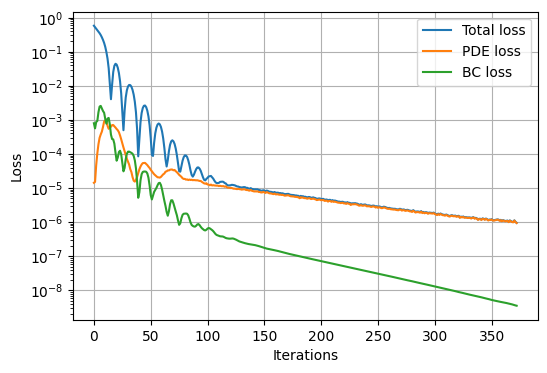

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.semilogy(loss_history_all[k0]["total"], label='Total loss')
plt.semilogy(loss_history_all[k0]["pde"], label='PDE loss')
plt.semilogy(loss_history_all[k0]["bc"], label='BC loss')

plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
torch.save({
    "model_layer": model_layer.state_dict(),
    "model_half": model_half.state_dict(),
    "c": c.detach().cpu()
}, "dispersion_pinn.pth")

print("Model saved.")


Model saved.


In [13]:
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

L = geom["L"]   # layer thickness
H_trunc = geom["H_trunc"]   # half-space depth



In [14]:
# z-grid for plotting / post-processing

z_layer = torch.linspace(-L, 0.0, 200).reshape(-1, 1).to(DEVICE)
z_half  = torch.linspace(0.0, H_trunc, 200).reshape(-1, 1).to(DEVICE)



In [15]:
with torch.no_grad():

    scale = 1e-2
# Layer (complex amplitude)   
    
V_layer = model_layer(z_layer)
V_R = V_layer[:, 0:1]
V_I =  V_layer[:, 1:2]
# Half-space (real amplitude)
V_half =  model_half(z_half)



In [16]:
import sys, platform
import torch
print("sys.executable:", sys.executable)
print("python:", platform.python_version())
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

sys.executable: c:\Users\tdiks\Documents\PhD NITH\research paper\7th paper\piezo-visco PINN\pinn_FGM_loosley\.venv\Scripts\python.exe
python: 3.12.3
torch: 2.11.0+cpu
cuda available: False


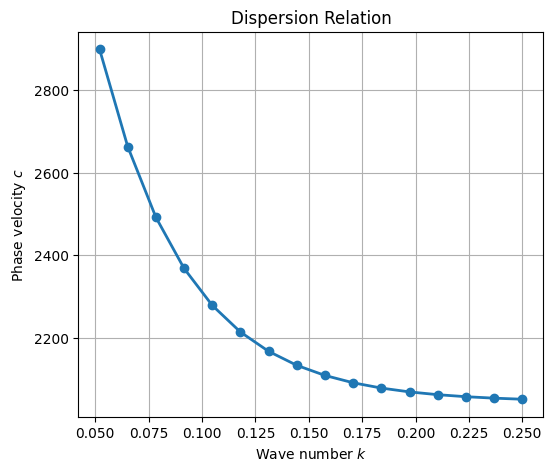

In [17]:
import matplotlib.pyplot as plt
import torch

# dispersion: shape (N, 2) → [k, c]
dispersion = torch.tensor(dispersion)
# dispersion: shape (N, 2) → [k, c]
k_vals = dispersion[:, 0]
c_vals = dispersion[:, 1]


plt.figure(figsize=(6,5))
plt.plot(k_vals, c_vals, 'o-', linewidth=2, markersize=6)

plt.xlabel("Wave number $k$")
plt.ylabel("Phase velocity $c$")
plt.title("Dispersion Relation")
plt.grid(True)

plt.show()



C:\Users\tdiks\AppData\Local\Temp\ipykernel_16716\734591668.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dispersion = torch.tensor(dispersion)


Layer properties:
  μ₄₄ = 3.00e+10 Pa
  ρ = 7500 kg/m³
  c_ref = √(μ₄₄/ρ) = 2000.0 m/s
  H = 2


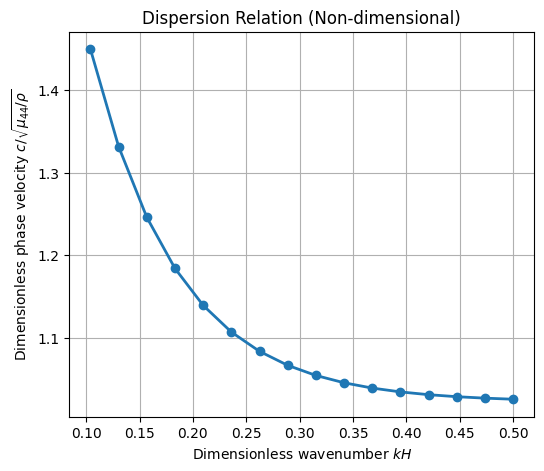


Dispersion data (non-dimensional):
   kH        c/c_ref
   0.104     1.449
   0.130     1.331
   0.157     1.246
   0.183     1.184
   0.210     1.139
   0.236     1.107
   0.262     1.084
   0.289     1.067
   0.315     1.054
   0.342     1.045
   0.368     1.039
   0.394     1.034
   0.421     1.031
   0.447     1.029
   0.474     1.027
   0.500     1.026


In [18]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# Your dispersion data
dispersion = torch.tensor(dispersion)
k_vals = dispersion[:, 0]
c_vals = dispersion[:, 1]

# Material properties for layer (from your config)
mu44_layer = 0.3e11 # Pa
rho_layer = 7500.0 # kg/m³
H = 2 # Layer thickness (non-dimensional)

# Calculate reference velocity: √(μ₆₆/ρ) for layer
c_ref_layer = np.sqrt(mu44_layer / rho_layer)# Reference shear speed

print(f"Layer properties:")
print(f"  μ₄₄ = {mu44_layer:.2e} Pa")
print(f"  ρ = {rho_layer:.0f} kg/m³")
print(f"  c_ref = √(μ₄₄/ρ) = {c_ref_layer:.1f} m/s")
print(f"  H = {H}")

# Non-dimensionalize
kH = k_vals * H                     # Dimensionless wavenumber
c_norm = c_vals / c_ref_layer       # Dimensionless phase velocity

# Plot
plt.figure(figsize=(6, 5))
plt.plot(kH, c_norm, 'o-', linewidth=2, markersize=6)

plt.xlabel("Dimensionless wavenumber $kH$")
plt.ylabel("Dimensionless phase velocity $c/\\sqrt{\\mu_{44}/\\rho}$")
plt.title("Dispersion Relation (Non-dimensional)")
plt.grid(True)

plt.show()

# Print the data
print("\nDispersion data (non-dimensional):")
print("   kH        c/c_ref")
for i in range(len(kH)):
    print(f"   {kH[i]:.3f}     {c_norm[i]:.3f}")

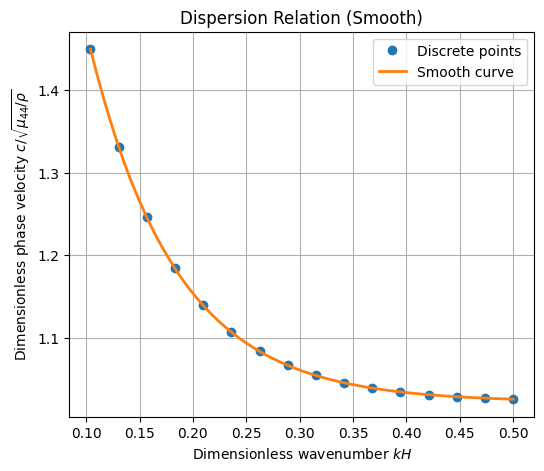

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# If not already done, convert tensors to numpy arrays
kH_np = kH.cpu().numpy() if hasattr(kH, 'cpu') else np.array(kH)
c_norm_np = c_norm.cpu().numpy() if hasattr(c_norm, 'cpu') else np.array(c_norm)

# Sort values for interpolation (required for spline)
sort_idx = np.argsort(kH_np)
kH_sorted = kH_np[sort_idx]
c_norm_sorted = c_norm_np[sort_idx]

# Create smooth curve using cubic spline
kH_smooth = np.linspace(kH_sorted.min(), kH_sorted.max(), 300)
spline = make_interp_spline(kH_sorted, c_norm_sorted, k=2)
c_norm_smooth = spline(kH_smooth)

# Plot both discrete points and smooth curve
plt.figure(figsize=(6, 5))
plt.plot(kH_sorted, c_norm_sorted, 'o', label='Discrete points')
plt.plot(kH_smooth, c_norm_smooth, '-', label='Smooth curve', linewidth=2)
plt.xlabel("Dimensionless wavenumber $kH$")
plt.ylabel("Dimensionless phase velocity $c/\\sqrt{\\mu_{44}/\\rho}$")
plt.title("Dispersion Relation (Smooth)")
plt.grid(True)
plt.legend()
plt.show()

In [20]:
# Save PINN dispersion data
np.savetxt(
    "PINN_dispersion.csv",
    np.column_stack((kH_sorted, c_norm_sorted)),
    delimiter=",",
    header="kH,c_pinn",
    comments=""
)


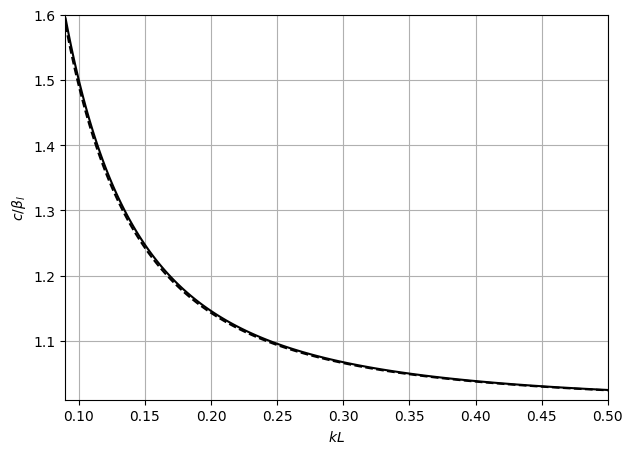

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv, yv
from numpy.lib.scimath import sqrt

# Parameters
rho2 = 2800
rho1 = 7500
L = 2

mu_h = 0.28e11
mu_l = 0.3e11

alpha1 = 0.2
alpha2 = 0.9

s = 100
K = mu_l/(s*L)

P1 = 1e7
P2 = 1e7

beta_l = np.sqrt(mu_l / rho1)
beta_h = np.sqrt(mu_h / rho2)

# Grid (same as MATLAB domain)
x = np.linspace(0.09, 0.5, 400)
y = np.linspace(1.01, 1.6, 400)
X, Y = np.meshgrid(x, y)

# Core expressions
Lambda_l = (X / L)**2 * (Y**2 - 1 - P1 / mu_l)
Lambda_h = sqrt(1 + P2/mu_h - (Y * beta_l / beta_h)**2)

xi0 = sqrt(Lambda_l) / alpha1
xiL = xi0 * (1 - alpha1 * L)

# Bessel
J0_0 = jv(0, xi0)
J1_0 = jv(1, xi0)
Y0_0 = yv(0, xi0)
Y1_0 = yv(1, xi0)

J0_L = jv(0, xiL)
J1_L = jv(1, xiL)
Y0_L = yv(0, xiL)
Y1_L = yv(1, xiL)

# LHS & RHS
denom = (J0_0 * Y1_L - Y0_0 * J1_L)
denom[np.abs(denom) < 1e-10] = np.nan

LHS = (J1_0 * Y1_L - Y1_0 * J1_L) / denom

RHS = (K * mu_h * (alpha2 + (X / L) * Lambda_h)) / (
    mu_l * sqrt(Lambda_l) *
    (mu_h * (alpha2 + (X / L) * Lambda_h) + K)
)

F = np.real(LHS - RHS)

# Plot (exact MATLAB equivalent)
plt.figure(figsize=(7,5))
plt.contour(X, Y, F, levels=[-1e-3, 1e-3], colors='k')
plt.xlabel(r'$kL$')
plt.ylabel(r'$c/\beta_l$')
plt.grid(True)

plt.show()

In [22]:
print(np.min(F), np.max(F))

-0.7756705835776003 0.541822005402023


<Figure size 640x480 with 0 Axes>

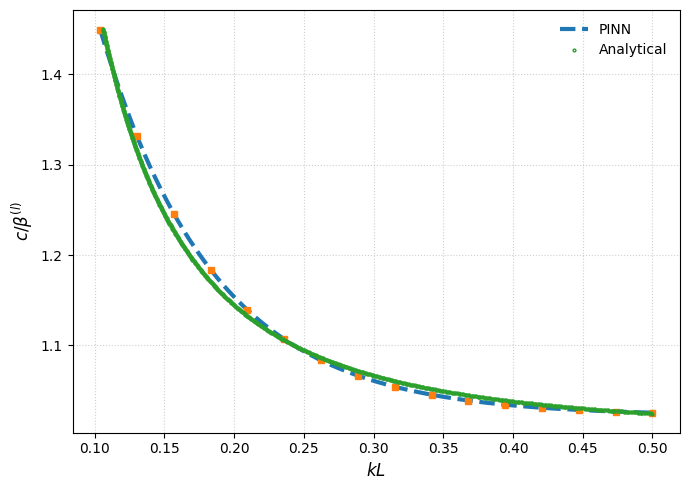

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv, yv
from numpy.lib.scimath import sqrt
from scipy.interpolate import make_interp_spline

# ==============================
# LOAD PINN DATA
# ==============================
pinn = np.loadtxt("PINN_dispersion.csv", delimiter=",", skiprows=1)
kH = pinn[:, 0]
c_pinn = pinn[:, 1]

# ==============================
# PARAMETERS (same as yours)
# ==============================
rho2 = 2800
rho1 = 7500
L = 2

mu_h = 0.28e11
mu_l = 0.3e11

alpha1 = 0.2
alpha2 = 0.9

s = 100
K = mu_l/(s*L)

P1 = 1e7
P2 = 1e7

beta_l = np.sqrt(mu_l / rho1)
beta_h = np.sqrt(mu_h / rho2)

# ==============================
# GRID
# ==============================
x = np.linspace(0.09, 0.5, 400)
y = np.linspace(1.01, 1.45, 400)
X, Y = np.meshgrid(x, y)

# ==============================
# ANALYTICAL FUNCTION
# ==============================
Lambda_l = (X / L)**2 * (Y**2 - 1 - P1 / mu_l)
Lambda_h = sqrt(1 + P2/mu_h - (Y * beta_l / beta_h)**2)

xi0 = sqrt(Lambda_l) / alpha1
xiL = xi0 * (1 - alpha1 * L)

J0_0 = jv(0, xi0)
J1_0 = jv(1, xi0)
Y0_0 = yv(0, xi0)
Y1_0 = yv(1, xi0)

J0_L = jv(0, xiL)
J1_L = jv(1, xiL)
Y0_L = yv(0, xiL)
Y1_L = yv(1, xiL)

denom = (J0_0 * Y1_L - Y0_0 * J1_L)
denom[np.abs(denom) < 1e-10] = np.nan

LHS = (J1_0 * Y1_L - Y1_0 * J1_L) / denom

RHS = (K * mu_h * (alpha2 + (X / L) * Lambda_h)) / (
    mu_l * sqrt(Lambda_l) *
    (mu_h * (alpha2 + (X / L) * Lambda_h) + K)
)

F = np.real(LHS - RHS)

# ==============================
# 🔥 EXTRACT CONTOUR POINTS
# ==============================
cs = plt.contour(X, Y, F, levels=[0])

kH_ana = []
c_ana = []

kH_ana = []
c_ana = []

for seg in cs.allsegs[0]:   # level 0 contour
    kH_ana.extend(seg[:, 0])
    c_ana.extend(seg[:, 1])

        
kH_ana = np.array(kH_ana)
c_ana = np.array(c_ana)

plt.clf()  # clear temporary contour

# ==============================
# SORT analytical
# ==============================
idx = np.argsort(kH_ana)
kH_ana = kH_ana[idx]
c_ana = c_ana[idx]

# ==============================
# SMOOTH PINN
# ==============================
idx_p = np.argsort(kH)
kH_sorted = kH[idx_p]
c_pinn_sorted = c_pinn[idx_p]

kH_smooth = np.linspace(kH_sorted.min(), kH_sorted.max(), 300)
spline = make_interp_spline(kH_sorted, c_pinn_sorted, k=2)
c_pinn_smooth = spline(kH_smooth)

# ==============================
# FINAL PLOT
# ==============================
plt.figure(figsize=(7,5))

# PINN
plt.plot(kH_smooth, c_pinn_smooth, '--', linewidth=3, label='PINN')
plt.plot(kH, c_pinn, 's', markersize=5)

# Analytical
plt.plot(kH_ana, c_ana, 'o',
         markerfacecolor='none',
         markersize=2, label='Analytical')

plt.xlabel(r'$kL$', fontsize=12)
plt.ylabel(r'$c/\beta^{(l)}$', fontsize=12)

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

In [24]:
# ==============================
# ERROR COMPUTATION (CORRECT WAY)
# ==============================

import numpy as np

# ---- Ensure analytical data is sorted ----
idx = np.argsort(kH_ana)
kH_ana = kH_ana[idx]
c_ana = c_ana[idx]

# ---- Interpolate analytical solution onto PINN kH ----
c_ana_interp = np.interp(kH, kH_ana, c_ana)

# ---- Compute errors ----
abs_error = np.abs(c_pinn - c_ana_interp)
rel_error = abs_error / np.abs(c_ana_interp)

# ==============================
# PRINT TABLE
# ==============================
print("\nCOMPARISON TABLE")
print("kH        PINN c/cs   Analytical c/cs   Abs. Error   Rel. Error")

for i in range(len(kH)):
    print(f"{kH[i]:.4f}   {c_pinn[i]:.6f}   {c_ana_interp[i]:.6f}   {abs_error[i]:.3e}   {rel_error[i]:.3e}")

# ==============================
# SAVE CSV (FOR PAPER)
# ==============================
table = np.column_stack((kH, c_pinn, c_ana_interp, abs_error, rel_error))

np.savetxt(
    "comparison_table.csv",
    table,
    delimiter=",",
    header="kH,PINN_c/cs,Analytical_c/cs,Abs_Error,Rel_Error",
    comments=""
)

print("\nSaved: comparison_table.csv")

# ==============================
# ERROR METRICS (IMPORTANT FOR PAPER)
# ==============================
rmse = np.sqrt(np.mean(abs_error**2))
mae = np.mean(abs_error)
max_err = np.max(abs_error)

print("\nError Metrics:")
print(f"RMSE = {rmse:.4e}")
print(f"MAE  = {mae:.4e}")
print(f"Max Error = {max_err:.4e}")


COMPARISON TABLE
kH        PINN c/cs   Analytical c/cs   Abs. Error   Rel. Error
0.1040   1.449406   1.450000   5.939e-04   4.096e-04
0.1304   1.331491   1.314881   1.661e-02   1.263e-02
0.1568   1.245844   1.226484   1.936e-02   1.578e-02
0.1832   1.183935   1.170264   1.367e-02   1.168e-02
0.2096   1.139198   1.132427   6.771e-03   5.979e-03
0.2360   1.106907   1.105817   1.090e-03   9.854e-04
0.2624   1.083521   1.086428   2.907e-03   2.676e-03
0.2888   1.066592   1.071882   5.289e-03   4.934e-03
0.3152   1.054333   1.060701   6.368e-03   6.004e-03
0.3416   1.045462   1.051929   6.467e-03   6.148e-03
0.3680   1.039052   1.044927   5.875e-03   5.622e-03
0.3944   1.034412   1.039247   4.835e-03   4.652e-03
0.4208   1.031045   1.034578   3.533e-03   3.415e-03
0.4472   1.028611   1.030695   2.084e-03   2.022e-03
0.4736   1.026840   1.027432   5.918e-04   5.760e-04
0.5000   1.025550   1.024665   8.856e-04   8.642e-04

Saved: comparison_table.csv

Error Metrics:
RMSE = 8.2143e-03
MAE  = 

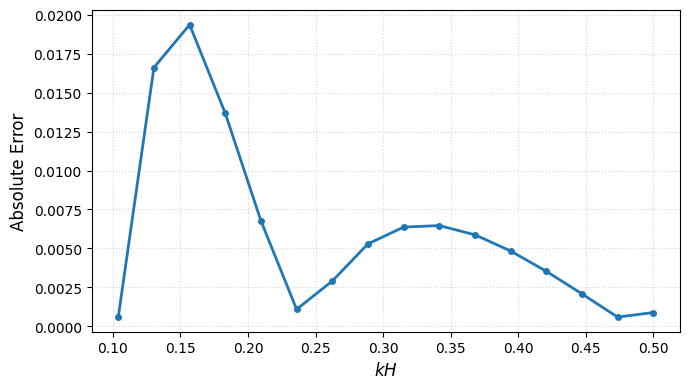

In [25]:
plt.figure(figsize=(7,4))

plt.plot(kH, abs_error, 'o-', linewidth=2, markersize=4)
plt.xlabel(r'$kH$', fontsize=12)
plt.ylabel('Absolute Error', fontsize=12)

plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

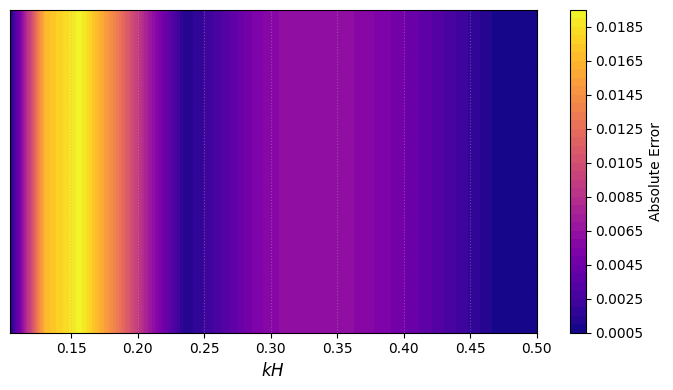

In [26]:
# ==============================
# Absolute error contour (fixed)
# ==============================

# artificial vertical axis
y = np.linspace(0, 1, 50)

# create meshgrid using PINN kH
KH, Y = np.meshgrid(kH, y)

# repeat error along vertical direction
Z = np.tile(abs_error, (len(y), 1))

# ==============================
# PLOT
# ==============================
plt.figure(figsize=(7,4))

cont = plt.contourf(KH, Y, Z, levels=40, cmap='plasma')
cbar = plt.colorbar(cont)
cbar.set_label('Absolute Error')

plt.xlabel(r'$kH$', fontsize=12)
plt.ylabel('', fontsize=10)
plt.yticks([])

plt.xlim([min(kH), max(kH)])
plt.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

In [27]:
# ==============================
# PREPARE CORRECT ARRAYS
# ==============================
# ensure analytical is sorted
idx = np.argsort(kH_ana)
kH_ana = kH_ana[idx]
c_ana = c_ana[idx]

# interpolate analytical onto PINN kH
c_ana_interp = np.interp(kH, kH_ana, c_ana)

pred = np.asarray(c_pinn).flatten()
true = np.asarray(c_ana_interp).flatten()

# ==============================
# ERROR COMPUTATION
# ==============================
err = pred - true
abs_err = np.abs(err)

L1   = np.mean(abs_err)
RMSE = np.sqrt(np.mean(err**2))
L2   = np.sqrt(np.sum(err**2))
Linf = np.max(abs_err)
relL2 = L2 / np.sqrt(np.sum(true**2))

labels = ['L1', 'RMSE', 'L2 norm', 'L∞', 'Rel L2']
values = [L1, RMSE, L2, Linf, relL2]

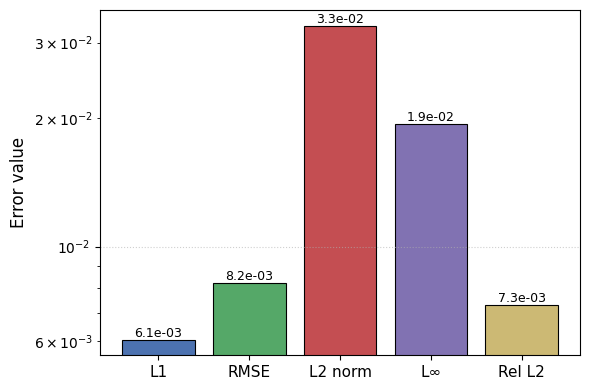

In [28]:
plt.figure(figsize=(6,4))

colors = ['#4C72B0','#55A868','#C44E52','#8172B2','#CCB974']
bars = plt.bar(labels, values, color=colors, edgecolor='black', linewidth=0.8)

plt.yscale('log')
plt.ylabel('Error value', fontsize=12)

# value labels (avoid overlap in log scale)
for b in bars:
    h = b.get_height()
    plt.text(b.get_x()+b.get_width()/2, h*1,
             f'{h:.1e}',
             ha='center', va='bottom', fontsize=9)

plt.grid(True, linestyle=':', axis='y', alpha=0.6)
plt.xticks(fontsize=11)
plt.tight_layout()
plt.show()